In [3]:
import torch
import json
import os

from data.ae_dataset import AEDataset
from torch import linalg as LA
import numpy as np
from matplotlib.pyplot import plot
from tqdm import tqdm
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Markdown, display_markdown # to display images

# Global variable

In [4]:
rec_seq = torch.load("model_outputs/rec_seq_0724_204251_v9.pt")   # [10377, 10, 512]

In [5]:
ori_seq = torch.load("model_outputs/ori_seq_0724_204251_v9.pt")   # [10377, 10, 512]

In [6]:
all_emb_path = os.path.join("./processed_data", "mean_pooled_emb.pt")
all_emb = torch.load(all_emb_path)   # [141245, 512]

In [7]:
all_md_path = os.path.join("./processed_data", "emb_idx_filtered.json")
with open(all_md_path, 'r') as fp:
    all_md = json.load(fp)   # .shape[0]=141245

# Display norm

In [8]:
# For rec_seq
all_rec_norm_list = []
for seq in rec_seq:
    # seq: [10, 512]
    norm_list = []
    for emb in seq:
        # emb: [512]
        norm_list.append(LA.norm(emb).item())
    all_rec_norm_list.append(norm_list)

In [9]:
# For ori_seq
all_ori_norm_list = []
for seq in ori_seq:
    # seq: [10, 512]
    norm_list = []
    for emb in seq:
        # emb: [512]
        norm_list.append(LA.norm(emb).item())
    all_ori_norm_list.append(norm_list)

In [10]:
assert len(all_rec_norm_list) == len(all_ori_norm_list)

In [93]:
all_rec_norm_list[9]

[0.9779276847839355,
 0.973573625087738,
 1.0275431871414185,
 0.40107983350753784,
 0.4880833625793457,
 0.6097118258476257,
 0.676997721195221,
 0.8470544219017029,
 0.7521040439605713,
 0.5765875577926636]

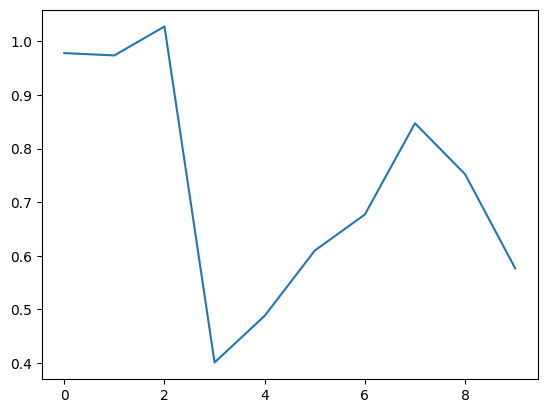

In [94]:
plot(range(10), all_rec_norm_list[9])

# Find the closest part

In [12]:
# find the pad for ori, compute the 'mask'
eps = 0.5
threshold = 0.5

## Find part in the entire part embedding space

In [72]:
def find_closest(emb, indices=list(range(len(all_emb)))):
    delta = all_emb - emb   # [141245, 512]
#     print(delta.shape)
    dist = LA.norm(delta, dim=1)   #[141245]
#     print(dist.shape)
    indices = torch.LongTensor(indices)
    min_val = torch.min(torch.index_select(dist, 0, indices)).item()
#     idx = dist.argmin()   # If there are multiple minimal values then the indices of the first minimal value are returned.
    idx = (dist == min_val).nonzero(as_tuple=True)[0][0]   # first [0]: (tensor([91286]),) second[0]: remove mupltiple values
#     sorted_dist, indices = torch.sort(dist)
#     print(indices[:100])
#     print(sorted_dist[:100])
#     print(dist[:10])
#     print(idx)
#     print(dist[idx])
    
    return idx.item()

In [73]:
all_rec_closest_emb_list = []
for i, seq in tqdm(enumerate(rec_seq[:10, :, :])):
    closest_emb_list = []
    for j, rec_emb in enumerate(seq):
        if all_rec_norm_list[i][j] < eps:
            break
        closest_emb_idx = find_closest(rec_emb)
        closest_emb_list.append(closest_emb_idx)
    all_rec_closest_emb_list.append(closest_emb_list)

10it [00:02,  3.55it/s]


In [102]:
all_ori_closest_emb_list = []
for i, seq in tqdm(enumerate(ori_seq[:10, :, :])):
    closest_emb_list = []
    for j, rec_emb in enumerate(seq):
        if all_ori_norm_list[i][j] < eps:
            break
        closest_emb_idx = find_closest(rec_emb)
        closest_emb_list.append(closest_emb_idx)
    all_ori_closest_emb_list.append(closest_emb_list)

10it [00:04,  2.27it/s]


In [74]:
all_rec_closest_emb_list

[[91286, 99916, 74102],
 [24160, 47198, 86656],
 [90792, 11038, 48540, 102414],
 [93995, 25065],
 [18003, 104101],
 [13875, 25043],
 [58667, 69556],
 [83671, 139079],
 [79231, 17919],
 [86655, 48717, 18786]]

In [103]:
all_ori_closest_emb_list

[[129259, 129260],
 [129260, 129259],
 [96139, 96143, 96146, 96148, 96149],
 [96140, 96147, 96142, 96143, 96151, 96148, 96149, 96141],
 [96141, 96143, 96140],
 [96142, 96143, 96140],
 [96143, 96147, 96142, 96150, 96151, 96152, 96146, 96139, 96148, 96149],
 [96146, 96143, 96139],
 [96147, 96143, 96140],
 [96148, 96143, 96139, 96140]]

In [33]:
all_md[129259]

'0000_79682_b75071d6_cf962214-059a-11ec-9f7a-02631ee0d5cb_0000'

## Find part in the same assembly (top-k)

In [32]:
def find_topk_closest(emb, k=10):
    
    delta = all_emb - emb   # [141245, 512]
    dist = LA.norm(delta, dim=1)   #[141245]
    sorted_dist, indices = torch.sort(dist)
    topk_indices = indices[:k]
    
    return topk_indices

In [34]:
def compute_aid_to_part_indice_map():
    the_map = dict()
    assert len(all_md) == all_emb.shape[0]
    for idx, md in enumerate(all_md):
        aid = '_'.join(md.split('_')[1:3])
        if aid in the_map:
            the_map[aid].append(idx)
        else:
            the_map[aid] = []
            the_map[aid].append(idx)
    
    return the_map

In [35]:
aid_to_part_indice_map = compute_aid_to_part_indice_map()

In [ ]:
def find_part(emb, indices):
    part_idx_list = []
    for ind in indices:
        img_name = all_md[ind]
        aid = '_'.join(img_name.split('_')[1:3])
        constraint_indices = aid_to_part_indice_map[aid]
        part_idx = find_closest(emb, constraint_indices)
        part_idx_list.append(part_idx)   # TBD: Unsure about the returned datatype
    
    return part_idx_list
    

In [ ]:
all_rec_closest_emb_list = []
for i, seq in tqdm(enumerate(rec_seq[:1, :, :])):
    closest_emb_list = []
    for j, rec_emb in enumerate(seq):
        if all_rec_norm_list[i][j] < eps:
            break
        if j==0:
            cand_central_parts = find_topk_closest(rec_emb)
        else:
            for cand in cand_central_parts:
                part_idx = find_part()   # TBD
        # TBD
    all_rec_closest_emb_list.append(closest_emb_list)

# Display parts

In [63]:
def image_grid(imgs, rows, cols, resize=False, texts=None):
        
    if resize:
        scale = 1/3
        w, h = imgs[0].size
        newsize = (int(w*scale), int(h*scale))
        imgs = [ img.resize(newsize) for img in imgs]

    # Width and height of the (first) image
    w, h = imgs[0].size

    # Calculate grid width and height
    grid_w = cols*w   # number of columns * width
    grid_h = rows*h
    grid = Image.new('RGB', size=(grid_w, grid_h), color="white")

    # Draw the grid
    I1 = ImageDraw.Draw(grid)
    
    for i, img in enumerate(imgs):
        x = i%cols*w
        y = i//cols*h
        grid.paste(img, box=(x, y))   # put img to the correct grid cell
        if texts is not None:
            assert len(texts) ==  len(imgs), "Should have text for each image"
            text = texts[i]
            I1.text((x, y), text, fill=(0, 0, 0))
    return grid

def create_image_grid_for_examples(png_paths):
#     png_paths = []
#     json_paths = []
    num_images_per_row = 10
    k = num_images_per_row*1
#     for s in file_stems:
#         chunk = s[0:4]
#         chunk_path = image_path / chunk
#         png_path = chunk_path / (s + ".png")
#         if png_path.exists():
#             png_paths.append(png_path)
#             json_path =  chunk_path / (s.rpartition("_")[0] + ".json")
#             assert json_path.exists(), "Json files doesn't exist"
#             json_paths.append(json_path)

            
    total_num_images = len(png_paths)
#     if total_num_images == 0:
#         print("No bodies found")
#         return None
    
    if k > total_num_images:
        k = total_num_images
#     chosen_indices = random.sample(range(total_num_images), k=k)
  
    imgs = []  # Stores images to be displayed
#     texts = []
    for i in range(k):
        png_file = png_paths[i]
#         json_file = json_paths[i]
        img = Image.open(png_file)
        imgs.append(img)
        
    num_images = len(imgs)
#     sq_max = math.ceil(math.sqrt(num_images))
#     grid = image_grid(imgs, sq_max, sq_max, resize=False, texts=None)
    grid = image_grid(imgs, 1, num_images, resize=True, texts=None)
    return grid

In [64]:
def extend_metadata_to_filepath(img_name_list_without_vid, vid):
    img_name_list_with_vid = []
    for i, im in enumerate(img_name_list_without_vid):
        img_name_list_with_vid.append(f'./raw_data/{vid}/{im}_00{vid}.png')
    
    return img_name_list_with_vid

In [65]:
def display_image_grid(msg, image_path):
    display(Markdown(msg))
#     file_stems = file_stem_dict[face_bin]
    img =  create_image_grid_for_examples(image_path)
    if img is not None:
        display(img)
    print(" ")
    print(" ")

In [66]:
img_md_list = []
for img_idx in all_rec_closest_emb_list[9]:
    img_md = all_md[img_idx]
    img_md_list.append(img_md)

In [67]:
vid = '00'
img_name_list = extend_metadata_to_filepath(img_md_list, vid)

msg

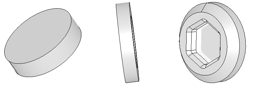

In [68]:
display_image_grid("msg", img_name_list)